PNG数: 13
edge_count_variable_gcn_accuracy_vs_current_edges.png
edge_count_variable_gcn_accuracy_vs_current_edges_log.png
edge_count_variable_gcn_accuracy_vs_keep_ratio.png
edge_count_variable_gcn_f1_recall_vs_keep_ratio.png
edge_count_variable_gcn_f1_vs_current_edges.png
edge_count_variable_gcn_f1_vs_current_edges_log.png
edge_count_variable_gcn_f1_vs_keep_ratio.png
edge_count_variable_gcn_precision_vs_current_edges.png
edge_count_variable_gcn_precision_vs_current_edges_log.png
edge_count_variable_gcn_precision_vs_keep_ratio.png
edge_count_variable_gcn_recall_vs_current_edges.png
edge_count_variable_gcn_recall_vs_current_edges_log.png
edge_count_variable_gcn_recall_vs_keep_ratio.png
[1/13] edge_count_variable_gcn_accuracy_vs_current_edges.png
[2/13] edge_count_variable_gcn_accuracy_vs_current_edges_log.png
[3/13] edge_count_variable_gcn_accuracy_vs_keep_ratio.png
[4/13] edge_count_variable_gcn_f1_recall_vs_keep_ratio.png
[5/13] edge_count_variable_gcn_f1_vs_current_edges.png
[6/13] edg

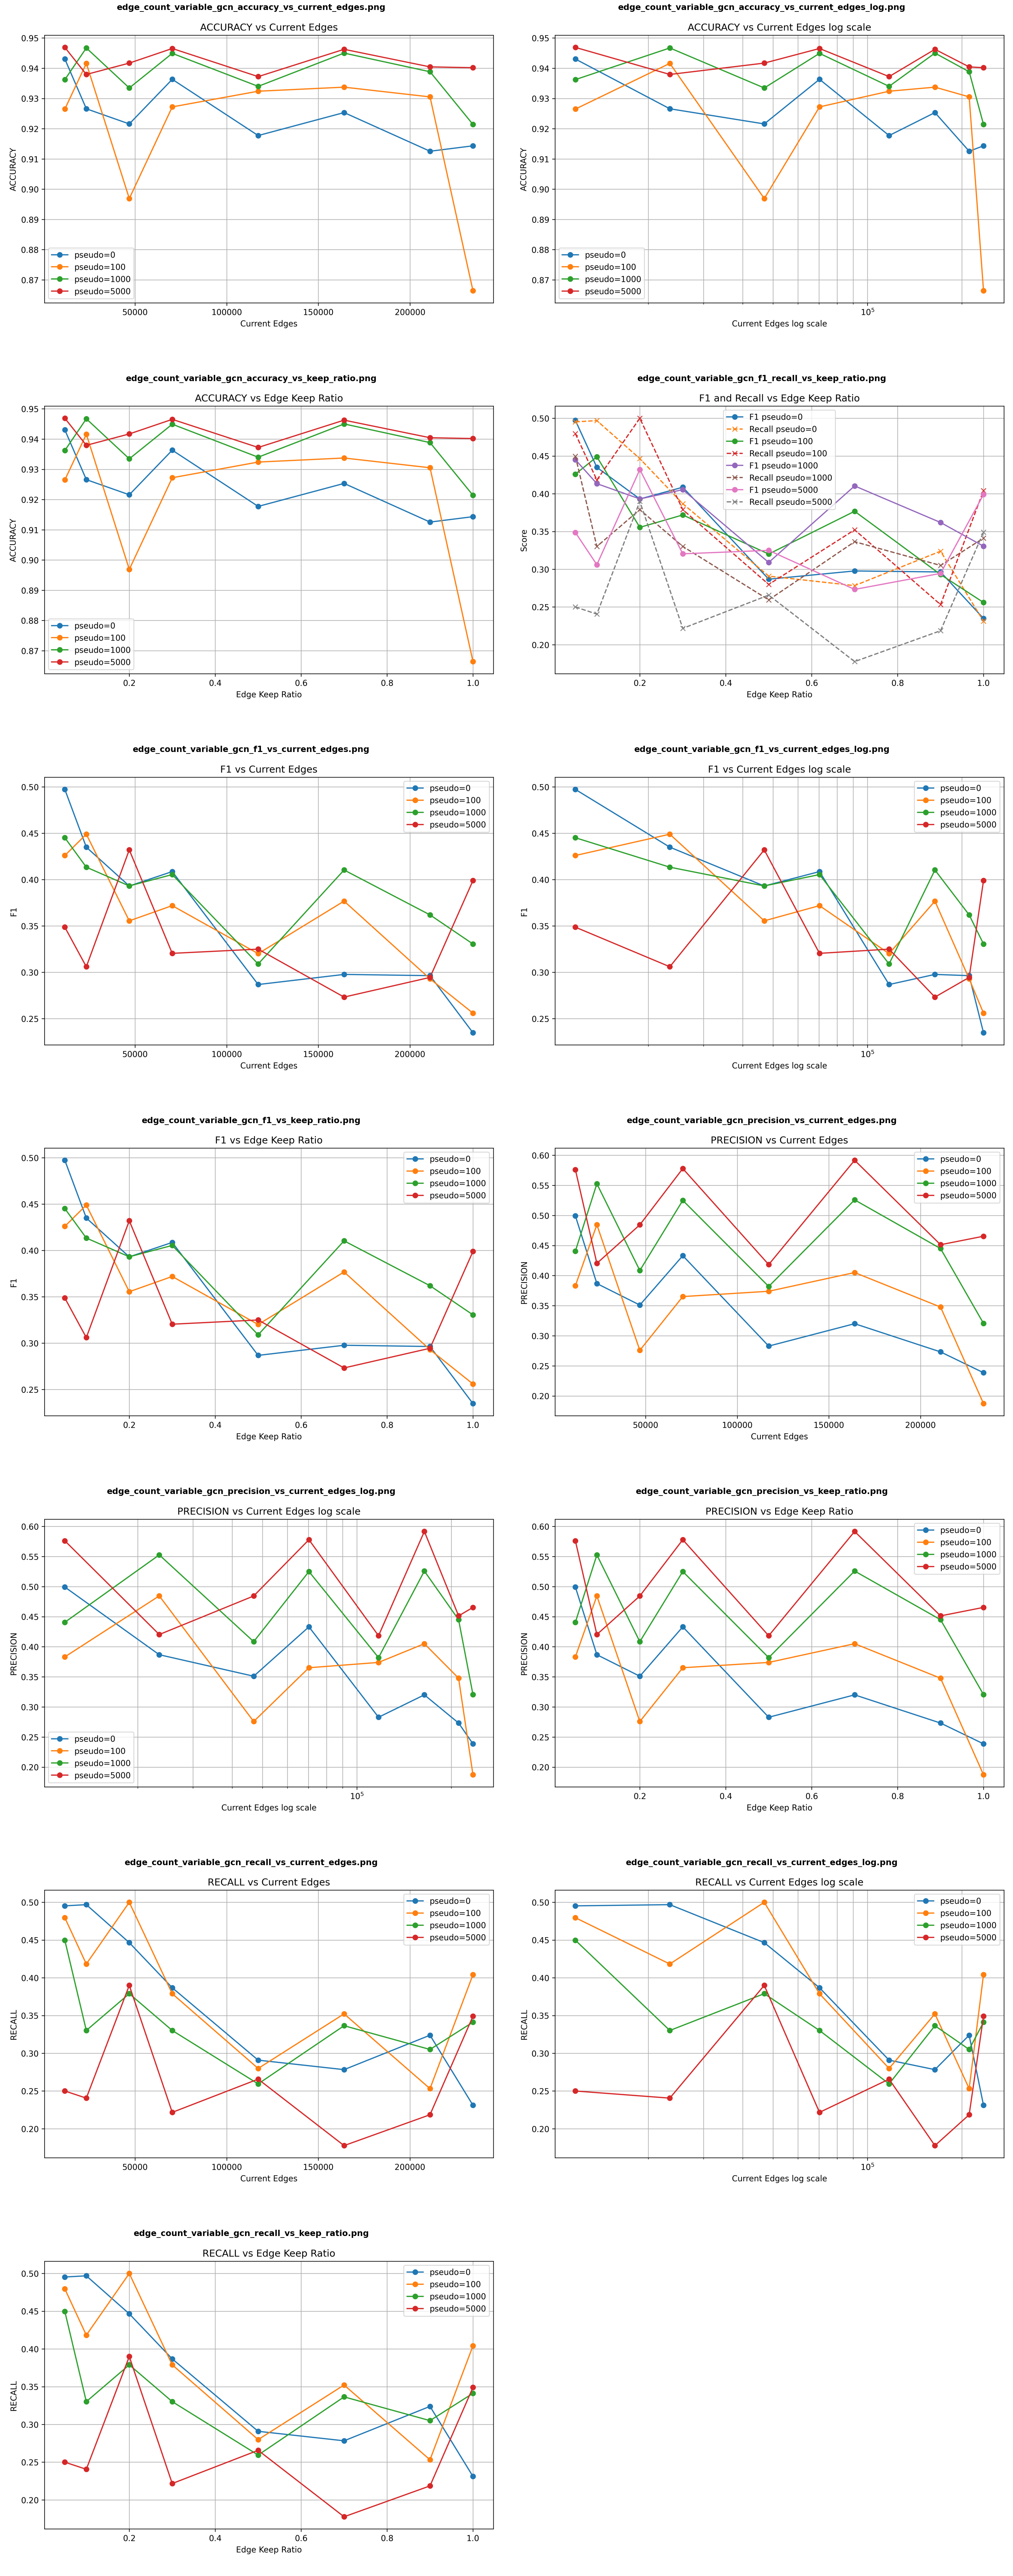

In [ ]:
# -*- coding: utf-8 -*-

import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops
from torch_geometric.nn import GCNConv


TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

SEED = 42

TRAIN_END_STEP = 34
VAL_END_STEP   = 39

EPOCHS       = 50
LR           = 0.001
WEIGHT_DECAY = 5e-4
HIDDEN_DIM   = 64
DROPOUT      = 0.5

LOG_EPOCH_INTERVAL = 5
BETWEENNESS_K = 100

EDGE_KEEP_RATIOS = [
    1.0,
    0.9,
    0.7,
    0.5,
    0.3,
    0.2,
    0.1,
    0.05,
]

PSEUDO_LIST = [
    0,
    100,
    1000,
    5000,
]

OUT_CSV = "edge_count_variable_gcn_results.csv"
PLOT_PREFIX = "edge_count_variable_gcn_desc"

START_TIME = time.time()


def elapsed():
    sec = int(time.time() - START_TIME)
    return f"{sec//3600:02d}:{(sec%3600)//60:02d}:{sec%60:02d}"


def log(msg):
    print(
        f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | +{elapsed()}] {msg}",
        flush=True,
    )


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


class GCN(torch.nn.Module):

    def __init__(self, in_dim, hidden_dim, out_dim=2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training)

        return self.lin(x)


def tune_threshold(y_true, prob_illicit):

    best_th = 0.5
    best_f1 = -1

    for th in np.arange(0.05, 0.96, 0.05):
        pred = (prob_illicit >= th).astype(int)

        f1 = f1_score(
            y_true,
            pred,
            pos_label=1,
            zero_division=0,
        )

        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    return best_th, best_f1


def make_edge_ranking(G, edges):

    log("edge ranking 開始")

    deg = dict(G.degree())
    pr = nx.pagerank(G)

    bet = nx.betweenness_centrality(
        G,
        k=BETWEENNESS_K,
        seed=SEED,
    )

    rows = []

    for u, v in edges:

        d = deg.get(u, 0) + deg.get(v, 0)
        p = pr.get(u, 0) + pr.get(v, 0)
        b = bet.get(u, 0) + bet.get(v, 0)

        score = d * 0.4 + p * 0.3 + b * 0.3

        rows.append({
            "u": u,
            "v": v,
            "degree_score": d,
            "pagerank_score": p,
            "betweenness_score": b,
            "edge_score": score,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values("edge_score", ascending=False)

    log("edge ranking 完了")

    return df


def prune_edges(df_edge_rank, keep_ratio):

    keep_n = int(len(df_edge_rank) * keep_ratio)
    keep_n = max(1, keep_n)

    df_keep = df_edge_rank.head(keep_n)

    return df_keep[["u", "v"]].values.tolist()


def run_gcn_training(
    X_raw,
    y_train_np,
    original_y_np,
    time_steps_np,
    edge_index,
    device,
    current_edges,
    original_edges,
):

    train_mask_np = (
        (y_train_np != -1)
        &
        (time_steps_np <= TRAIN_END_STEP)
    )

    val_mask_np = (
        (original_y_np != -1)
        &
        (time_steps_np > TRAIN_END_STEP)
        &
        (time_steps_np <= VAL_END_STEP)
    )

    test_mask_np = (
        (original_y_np != -1)
        &
        (time_steps_np > VAL_END_STEP)
    )

    scaler = StandardScaler()

    X_scaled = X_raw.copy()
    X_scaled[train_mask_np] = scaler.fit_transform(X_scaled[train_mask_np])
    X_scaled[~train_mask_np] = scaler.transform(X_scaled[~train_mask_np])

    data = Data(
        x=torch.tensor(X_scaled, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y_train_np, dtype=torch.long),
    )

    data.train_mask = torch.tensor(train_mask_np, dtype=torch.bool)
    data.val_mask = torch.tensor(val_mask_np, dtype=torch.bool)
    data.test_mask = torch.tensor(test_mask_np, dtype=torch.bool)

    data = data.to(device)

    model = GCN(
        in_dim=data.x.size(1),
        hidden_dim=HIDDEN_DIM,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    train_y = data.y[data.train_mask]

    counts = torch.bincount(
        train_y,
        minlength=2,
    ).float()

    weights = counts.sum() / (counts + 1e-9)
    weights = weights / weights.mean()
    weights = weights.to(device)

    best_f1 = -1
    best_state = None

    for epoch in range(1, EPOCHS + 1):

        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)

        loss = F.cross_entropy(
            out[data.train_mask],
            data.y[data.train_mask],
            weight=weights,
        )

        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():

            out = model(data.x, data.edge_index)
            prob = F.softmax(out, dim=1)

            val_prob = prob[data.val_mask, 0].cpu().numpy()

            val_true = (
                original_y_np[val_mask_np] == 0
            ).astype(int)

            th, f1 = tune_threshold(
                val_true,
                val_prob,
            )

        if f1 > best_f1:

            best_f1 = f1
            best_state = {
                "model": model.state_dict(),
                "th": th,
            }

        if (
            epoch == 1
            or epoch % LOG_EPOCH_INTERVAL == 0
            or epoch == EPOCHS
        ):

            log(
                f"epoch={epoch:03d}/{EPOCHS} "
                f"loss={loss.item():.6f} "
                f"val_f1={f1:.4f} "
                f"best={best_f1:.4f} "
                f"current_edges={current_edges} "
                f"original_edges={original_edges}"
            )

    model.load_state_dict(best_state["model"])
    model.eval()

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        prob = F.softmax(out, dim=1)

    test_prob = prob[data.test_mask, 0].cpu().numpy()

    test_true = (
        original_y_np[test_mask_np] == 0
    ).astype(int)

    test_pred = (
        test_prob >= best_state["th"]
    ).astype(int)

    report = classification_report(
        test_true,
        test_pred,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(test_true, test_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    return {
        "f1": report["1"]["f1-score"],
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "accuracy": report["accuracy"],
        "threshold": best_state["th"],
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def plot_results(df_result):

    log("plot開始")

    metrics = [
        "f1",
        "recall",
        "precision",
        "accuracy",
    ]

    for metric in metrics:

        plt.figure(figsize=(12, 7))

        for pseudo_n in sorted(df_result["pseudo_top_n"].unique()):

            df_plot = (
                df_result[
                    df_result["pseudo_top_n"] == pseudo_n
                ]
                .sort_values(
                    "keep_ratio",
                    ascending=True,
                )
            )

            plt.plot(
                df_plot["keep_ratio"],
                df_plot[metric],
                marker="o",
                linewidth=2,
                label=f"pseudo={pseudo_n}",
            )

        plt.gca().invert_xaxis()

        plt.xlabel("Edge Keep Ratio")
        plt.ylabel(metric.upper())
        plt.title(f"{metric.upper()} vs Edge Keep Ratio descending")
        plt.grid(True)
        plt.legend()

        out_png = f"{PLOT_PREFIX}_{metric}_vs_keep_ratio_desc.png"

        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()

        log(f"plot保存: {out_png}")

    for metric in metrics:

        plt.figure(figsize=(12, 7))

        for pseudo_n in sorted(df_result["pseudo_top_n"].unique()):

            df_plot = (
                df_result[
                    df_result["pseudo_top_n"] == pseudo_n
                ]
                .sort_values(
                    "current_edges",
                    ascending=True,
                )
            )

            plt.plot(
                df_plot["current_edges"],
                df_plot[metric],
                marker="o",
                linewidth=2,
                label=f"pseudo={pseudo_n}",
            )

        plt.gca().invert_xaxis()

        plt.xlabel("Current Edges")
        plt.ylabel(metric.upper())
        plt.title(f"{metric.upper()} vs Current Edges descending")
        plt.grid(True)
        plt.legend()

        out_png = f"{PLOT_PREFIX}_{metric}_vs_current_edges_desc.png"

        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()

        log(f"plot保存: {out_png}")

    for metric in metrics:

        plt.figure(figsize=(12, 7))

        for pseudo_n in sorted(df_result["pseudo_top_n"].unique()):

            df_plot = (
                df_result[
                    df_result["pseudo_top_n"] == pseudo_n
                ]
                .sort_values(
                    "current_edges",
                    ascending=True,
                )
            )

            plt.plot(
                df_plot["current_edges"],
                df_plot[metric],
                marker="o",
                linewidth=2,
                label=f"pseudo={pseudo_n}",
            )

        plt.xscale("log")
        plt.gca().invert_xaxis()

        plt.xlabel("Current Edges log scale")
        plt.ylabel(metric.upper())
        plt.title(f"{metric.upper()} vs Current Edges log scale descending")
        plt.grid(True, which="both")
        plt.legend()

        out_png = f"{PLOT_PREFIX}_{metric}_vs_current_edges_log_desc.png"

        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.show()

        log(f"plot保存: {out_png}")

    plt.figure(figsize=(12, 7))

    for pseudo_n in sorted(df_result["pseudo_top_n"].unique()):

        df_plot = (
            df_result[
                df_result["pseudo_top_n"] == pseudo_n
            ]
            .sort_values(
                "keep_ratio",
                ascending=True,
            )
        )

        plt.plot(
            df_plot["keep_ratio"],
            df_plot["f1"],
            marker="o",
            linewidth=2,
            label=f"F1 pseudo={pseudo_n}",
        )

        plt.plot(
            df_plot["keep_ratio"],
            df_plot["recall"],
            marker="x",
            linestyle="--",
            linewidth=2,
            label=f"Recall pseudo={pseudo_n}",
        )

    plt.gca().invert_xaxis()

    plt.xlabel("Edge Keep Ratio")
    plt.ylabel("Score")
    plt.title("F1 and Recall vs Edge Keep Ratio descending")
    plt.grid(True)
    plt.legend()

    out_png = f"{PLOT_PREFIX}_f1_recall_vs_keep_ratio_desc.png"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    log(f"plot保存: {out_png}")

    log("plot完了")


def main():

    set_seed()

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    log(f"device={device}")

    log("CSV読み込み")

    df_f = pd.read_csv(TXS_FEATURES)
    df_c = pd.read_csv(TXS_CLASSES)
    df_e = pd.read_csv(TXS_EDGES)

    log(
        f"features={df_f.shape} "
        f"classes={df_c.shape} "
        f"edges={df_e.shape}"
    )

    id_col_f = df_f.columns[0]
    id_col_c = df_c.columns[0]

    df = df_f.merge(
        df_c,
        left_on=id_col_f,
        right_on=id_col_c,
        how="left",
    )

    ids = df[id_col_f].astype(int).values

    id2idx = {
        int(v): i
        for i, v in enumerate(ids)
    }

    y_np = df["class"].map(
        lambda x:
            0 if int(x) == 1
            else 1 if int(x) == 2
            else -1
    ).values

    original_y_np = y_np.copy()

    time_steps_np = df["Time step"].astype(int).values

    exclude_cols = {
        id_col_f,
        id_col_c,
        "class",
        "Time step",
    }

    feature_cols = [
        c
        for c in df.columns
        if c not in exclude_cols
    ]

    X = df[feature_cols]

    X = X.apply(
        pd.to_numeric,
        errors="coerce",
    )

    X = X.replace(
        [np.inf, -np.inf],
        np.nan,
    ).fillna(0)

    X_raw = X.values.astype(np.float32)

    log(f"feature_dim={X_raw.shape[1]}")

    edges = []

    col0, col1 = df_e.columns[:2]

    for u, v in zip(df_e[col0], df_e[col1]):

        u = int(u)
        v = int(v)

        if u in id2idx and v in id2idx:
            edges.append([id2idx[u], id2idx[v]])

    original_edges = len(edges)

    log(f"original_edges={original_edges}")

    G_full = nx.Graph()
    G_full.add_edges_from(edges)

    log(
        f"full graph "
        f"nodes={G_full.number_of_nodes()} "
        f"edges={G_full.number_of_edges()}"
    )

    df_edge_rank = make_edge_ranking(
        G_full,
        edges,
    )

    results = []

    total_runs = len(EDGE_KEEP_RATIOS) * len(PSEUDO_LIST)
    run_count = 0

    for keep_ratio in EDGE_KEEP_RATIOS:

        log("=" * 60)
        log(f"EDGE KEEP RATIO = {keep_ratio}")

        edges_keep = prune_edges(
            df_edge_rank,
            keep_ratio,
        )

        current_edges = len(edges_keep)

        reduction = 1.0 - current_edges / original_edges

        log(
            f"edge pruning "
            f"original={original_edges} "
            f"current={current_edges} "
            f"reduction={reduction:.4f}"
        )

        edge_index = torch.tensor(
            edges_keep,
            dtype=torch.long,
        ).T

        edge_index = to_undirected(edge_index)

        edge_index, _ = add_self_loops(
            edge_index,
            num_nodes=len(ids),
        )

        for pseudo_top_n in PSEUDO_LIST:

            run_count += 1

            log("-" * 60)

            log(
                f"run={run_count}/{total_runs} "
                f"keep_ratio={keep_ratio} "
                f"pseudo_top_n={pseudo_top_n} "
                f"current_edges={current_edges} "
                f"original_edges={original_edges}"
            )

            y_train_np = y_np.copy()

            if pseudo_top_n > 0:

                unknown_idx = np.where(y_np == -1)[0]

                pseudo_idx = unknown_idx[
                    :min(
                        pseudo_top_n,
                        len(unknown_idx),
                    )
                ]

                y_train_np[pseudo_idx] = 0

                log(
                    f"pseudo label付与 "
                    f"requested={pseudo_top_n} "
                    f"actual={len(pseudo_idx)}"
                )

            result = run_gcn_training(
                X_raw=X_raw,
                y_train_np=y_train_np,
                original_y_np=original_y_np,
                time_steps_np=time_steps_np,
                edge_index=edge_index,
                device=device,
                current_edges=current_edges,
                original_edges=original_edges,
            )

            results.append({
                "keep_ratio": keep_ratio,
                "pseudo_top_n": pseudo_top_n,
                "current_edges": current_edges,
                "original_edges": original_edges,
                "edge_reduction": reduction,
                "f1": result["f1"],
                "precision": result["precision"],
                "recall": result["recall"],
                "accuracy": result["accuracy"],
                "threshold": result["threshold"],
                "tn": result["tn"],
                "fp": result["fp"],
                "fn": result["fn"],
                "tp": result["tp"],
            })

            log(
                f"RESULT "
                f"keep_ratio={keep_ratio} "
                f"pseudo={pseudo_top_n} "
                f"edges={current_edges}/{original_edges} "
                f"F1={result['f1']:.4f} "
                f"Recall={result['recall']:.4f} "
                f"Precision={result['precision']:.4f} "
                f"Accuracy={result['accuracy']:.4f} "
                f"threshold={result['threshold']:.2f}"
            )

    df_result = pd.DataFrame(results)

    df_result.to_csv(
        OUT_CSV,
        index=False,
        encoding="utf-8-sig",
    )

    log(f"CSV保存: {OUT_CSV}")

    print()
    print("=" * 60)
    print("最終結果")
    print("=" * 60)

    print(
        df_result.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    plot_results(df_result)

    log("DONE")


if __name__ == "__main__":
    main()